# NB_06B — Modelos supervisados con thresholds, ranking y deciles

El NB_06 mostró que la clasificación binaria directa de señales técnicas candidatas tenía capacidad limitada, especialmente porque algunos modelos tendían a aprobar demasiadas señales. Sin embargo, también apareció una señal metodológicamente relevante: los scores de los modelos podían tener más valor como **ranking de oportunidades** que como clasificador binario duro.

Por eso este notebook separa tres preguntas:

1. ¿Qué ocurre si se evalúan los modelos con threshold fijo 0,50?
2. ¿Qué ocurre si se optimiza el threshold usando exclusivamente el conjunto de validación?
3. ¿Aportan valor los modelos como ranking, especialmente en Top 10%, Top 20% y por deciles de score?

## Decisión metodológica

El objetivo no es demostrar  que XGBoost o cualquier otro modelo “predice el mercado”. El objetivo es evaluar si un modelo supervisado puede **priorizar señales técnicas candidatas** mejor que el baseline técnico puro.

In [1]:
# ============================================================
# 0. Configuración general
# ============================================================

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as e:
    print('XGBoost no disponible. Se continuará sin XGBoost:', e)
    XGBOOST_AVAILABLE = False

RANDOM_STATE = 42
TARGET_COL = 'target_combo_positive'
OUTCOME_RETURN_COL = 'outcome_ret_combo'
YEAR_COL = 'signal_year'

BASE_DIR = Path.cwd()
INPUT_DATASET = BASE_DIR.parent / 'NB_05' / 'outputs_nb05' / 'dataset_supervisado_tecnico_v1.csv.zip'

# Fallbacks útiles por si se ejecuta fuera de la estructura prevista
if not INPUT_DATASET.exists():
    candidates = [
        BASE_DIR / 'dataset_supervisado_tecnico_v1.csv.zip',
        BASE_DIR / 'outputs_nb05' / 'dataset_supervisado_tecnico_v1.csv.zip',
        BASE_DIR.parent / 'outputs_nb05' / 'dataset_supervisado_tecnico_v1.csv.zip',
    ]
    for c in candidates:
        if c.exists():
            INPUT_DATASET = c
            break

OUT_DIR = BASE_DIR / 'outputs_nb06b'
FIG_DIR = OUT_DIR / 'figures'
CONF_DIR = FIG_DIR / 'confusion_matrices'
SCORE_DIR = FIG_DIR / 'score_distributions'
DECILE_DIR = FIG_DIR / 'deciles'
IMPORTANCE_DIR = FIG_DIR / 'feature_importance'

for p in [OUT_DIR, FIG_DIR, CONF_DIR, SCORE_DIR, DECILE_DIR, IMPORTANCE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('Directorio base:', BASE_DIR)
print('Dataset de entrada:', INPUT_DATASET)
print('Existe dataset:', INPUT_DATASET.exists())
print('Directorio de salida:', OUT_DIR)

Directorio base: /Users/rbr/TFM_MVP/JUNIO/NB_06
Dataset de entrada: /Users/rbr/TFM_MVP/JUNIO/NB_05/outputs_nb05/dataset_supervisado_tecnico_v1.csv.zip
Existe dataset: True
Directorio de salida: /Users/rbr/TFM_MVP/JUNIO/NB_06/outputs_nb06b


In [2]:
# ============================================================
# 1. Carga del dataset supervisado generado en NB_05
# ============================================================

if not INPUT_DATASET.exists():
    raise FileNotFoundError(
        'No se encontró dataset_supervisado_tecnico_v1.csv.zip. '
        'Coloca este notebook en JUNIO/NB_06/ y confirma que existe '
        '../NB_05/outputs_nb05/dataset_supervisado_tecnico_v1.csv.zip'
    )

df = pd.read_csv(INPUT_DATASET)

# Conversión de fechas si existen
for c in ['signal_date', 'entry_date']:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors='coerce')

print('Shape dataset:', df.shape)
print('Años:', sorted(df[YEAR_COL].dropna().unique().tolist()))
print('Target disponible:', TARGET_COL in df.columns)
print('Balance target:')
display(df[TARGET_COL].value_counts().rename('n').to_frame().assign(pct=lambda x: x['n'] / x['n'].sum()))

Shape dataset: (8155, 76)
Años: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Target disponible: True
Balance target:


,n,pct
target_combo_positive,,
0,4079,0.500184
1,4076,0.499816


## 2. Definición de matriz X y vector y

La matriz `X` contiene únicamente columnas que empiezan por `feat_`.  
El vector `y` es el target principal definido en NB_05: `target_combo_positive`.

Las columnas `outcome_` quedan excluidas del entrenamiento porque contienen información posterior a la entrada de la señal y producirían leakage.

In [3]:
# ============================================================
# 2. Construcción de X, y y control básico de leakage
# ============================================================

feature_cols = [c for c in df.columns if c.startswith('feat_')]
outcome_cols = [c for c in df.columns if c.startswith('outcome_')]
target_cols = [c for c in df.columns if c.startswith('target_')]
metadata_cols = [c for c in df.columns if c not in feature_cols + outcome_cols + target_cols]

print('Features iniciales:', len(feature_cols))
print('Outcomes excluidos:', len(outcome_cols))
print('Targets:', target_cols)
print('Metadata:', metadata_cols[:12], '...')

# Eliminar features constantes o con un único valor informativo
constant_features = []
for c in feature_cols:
    nunique = df[c].nunique(dropna=False)
    if nunique <= 1:
        constant_features.append(c)

feature_cols_model = [c for c in feature_cols if c not in constant_features]
print('Features constantes eliminadas:', len(constant_features))
print('Features finales para modelado:', len(feature_cols_model))

X_all = df[feature_cols_model].copy()
y_all = df[TARGET_COL].astype(int).copy()

num_cols = X_all.select_dtypes(include=['number', 'bool']).columns.tolist()
cat_cols = [c for c in X_all.columns if c not in num_cols]

print('Features numéricas:', len(num_cols))
print('Features categóricas:', len(cat_cols))
print('Categóricas:', cat_cols)

# Chequeo explícito de que no se filtraron outcomes dentro de X
leakage_in_X = [c for c in X_all.columns if c.startswith('outcome_') or c.startswith('target_')]
print('Columnas con leakage en X:', leakage_in_X)
assert len(leakage_in_X) == 0, 'Hay columnas de leakage dentro de X.'

Features iniciales: 59
Outcomes excluidos: 7
Targets: ['target_combo_positive', 'target_combo_ge_2pct', 'target_core_positive']
Metadata: ['signal_id', 'ticker', 'signal_date', 'entry_date', 'signal_year', 'signal_month', 'entry_execution_mode'] ...
Features constantes eliminadas: 16
Features finales para modelado: 43
Features numéricas: 40
Features categóricas: 3
Categóricas: ['feat_entry_family', 'feat_tk_confirmation_status', 'feat_chikou_diagnostic_status']
Columnas con leakage en X: []


In [4]:
# ============================================================
# 3. Splits temporales walk-forward
# ============================================================

folds = [
    {
        'fold': 1,
        'train_years': [2018, 2019, 2020, 2021],
        'val_year': 2022,
        'test_year': 2023,
    },
    {
        'fold': 2,
        'train_years': [2018, 2019, 2020, 2021, 2022],
        'val_year': 2023,
        'test_year': 2024,
    },
    {
        'fold': 3,
        'train_years': [2018, 2019, 2020, 2021, 2022, 2023],
        'val_year': 2024,
        'test_year': 2025,
    },
]

fold_summary = []
for f in folds:
    train_mask = df[YEAR_COL].isin(f['train_years'])
    val_mask = df[YEAR_COL].eq(f['val_year'])
    test_mask = df[YEAR_COL].eq(f['test_year'])
    fold_summary.append({
        'fold': f['fold'],
        'train_years': ','.join(map(str, f['train_years'])),
        'val_year': f['val_year'],
        'test_year': f['test_year'],
        'n_train': int(train_mask.sum()),
        'n_val': int(val_mask.sum()),
        'n_test': int(test_mask.sum()),
        'target_rate_train': y_all[train_mask].mean(),
        'target_rate_val': y_all[val_mask].mean(),
        'target_rate_test': y_all[test_mask].mean(),
    })

fold_summary_df = pd.DataFrame(fold_summary)
display(fold_summary_df)
fold_summary_df.to_csv(OUT_DIR / 'temporal_folds_nb06b.csv', index=False)

,fold,train_years,val_year,test_year,n_train,n_val,n_test,target_rate_train,target_rate_val,target_rate_test
0,1,"2018,2019,2020,2021",2022,2023,4423,472,907,0.503957,0.326271,0.450937
1,2,"2018,2019,2020,2021,2022",2023,2024,4895,907,1429,0.486823,0.450937,0.580826
2,3,"2018,2019,2020,2021,2022,2023",2024,2025,5802,1429,924,0.481213,0.580826,0.491342


## 4. Modelos evaluados

Se mantienen los cuatro modelos de referencia:

- `Dummy`: control trivial.
- `Logistic Regression`: baseline interpretable.
- `Random Forest`: modelo no lineal comparativo.
- `XGBoost`: modelo principal previsto inicialmente, si está disponible.

La comparación no busca elegir automáticamente el modelo más complejo, sino observar si alguno aporta capacidad de clasificación o ranking fuera de muestra.

In [5]:
# ============================================================
# 4. Preprocesamiento y modelos
# ============================================================

# OneHotEncoder cambió el argumento sparse/sparse_output entre versiones.
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=True)

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', make_ohe()),
        ]), cat_cols),
    ],
    remainder='drop'
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', make_ohe()),
        ]), cat_cols),
    ],
    remainder='drop'
)

models = {
    'Dummy': Pipeline([
        ('preprocess', preprocessor_tree),
        ('model', DummyClassifier(strategy='most_frequent')),
    ]),
    'LogisticRegression': Pipeline([
        ('preprocess', preprocessor_scaled),
        ('model', LogisticRegression(
            max_iter=2000,
            solver='liblinear',
            class_weight='balanced',
            random_state=RANDOM_STATE,
        )),
    ]),
    'RandomForest': Pipeline([
        ('preprocess', preprocessor_tree),
        ('model', RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            min_samples_leaf=25,
            class_weight='balanced_subsample',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = Pipeline([
        ('preprocess', preprocessor_tree),
        ('model', XGBClassifier(
            n_estimators=150,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            reg_lambda=5,
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=1,
        )),
    ])

print('Modelos incluidos:', list(models.keys()))

Modelos incluidos: ['Dummy', 'LogisticRegression', 'RandomForest', 'XGBoost']


In [6]:
# ============================================================
# 5. Funciones auxiliares
# ============================================================


def safe_auc(y_true, y_score):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, y_score)
    except Exception:
        return np.nan


def safe_pr_auc(y_true, y_score):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return average_precision_score(y_true, y_score)
    except Exception:
        return np.nan


def safe_brier(y_true, y_score):
    try:
        return brier_score_loss(y_true, y_score)
    except Exception:
        return np.nan


def predict_proba_positive(fitted_model, X):
    if hasattr(fitted_model, 'predict_proba'):
        proba = fitted_model.predict_proba(X)
        if proba.shape[1] == 1:
            # Caso extremo: modelo entrenado con una sola clase.
            classes = getattr(fitted_model.named_steps.get('model', fitted_model), 'classes_', np.array([0]))
            return np.ones(len(X)) if classes[0] == 1 else np.zeros(len(X))
        return proba[:, 1]
    # Fallback por si algún estimador no tiene predict_proba.
    if hasattr(fitted_model, 'decision_function'):
        scores = fitted_model.decision_function(X)
        return 1 / (1 + np.exp(-scores))
    return fitted_model.predict(X).astype(float)


def metrics_at_threshold(y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        'threshold': float(threshold),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': safe_auc(y_true, y_score),
        'pr_auc': safe_pr_auc(y_true, y_score),
        'brier': safe_brier(y_true, y_score),
        'predicted_positive_rate': float(y_pred.mean()),
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
    }


def find_best_threshold_by_f1(y_true_val, y_score_val):
    # Si el modelo produce un score constante, no hay threshold real que calibrar.
    # Se devuelve 0,50 para mantener comparabilidad y evitar conclusiones artificiales.
    if np.unique(np.round(y_score_val, 12)).size <= 1:
        y_pred = (y_score_val >= 0.50).astype(int)
        tmp = pd.DataFrame([{
            'threshold': 0.50,
            'f1': f1_score(y_true_val, y_pred, zero_division=0),
            'precision': precision_score(y_true_val, y_pred, zero_division=0),
            'recall': recall_score(y_true_val, y_pred, zero_division=0),
            'predicted_positive_rate': y_pred.mean(),
        }])
        return 0.50, tmp

    thresholds = np.linspace(0.05, 0.95, 181)
    rows = []
    for t in thresholds:
        y_pred = (y_score_val >= t).astype(int)
        rows.append({
            'threshold': t,
            'f1': f1_score(y_true_val, y_pred, zero_division=0),
            'precision': precision_score(y_true_val, y_pred, zero_division=0),
            'recall': recall_score(y_true_val, y_pred, zero_division=0),
            'predicted_positive_rate': y_pred.mean(),
        })
    tmp = pd.DataFrame(rows)
    # En caso de empate, se prefiere un threshold con menor tasa de positivos predichos.
    tmp = tmp.sort_values(['f1', 'predicted_positive_rate'], ascending=[False, True])
    best = tmp.iloc[0].to_dict()
    return float(best['threshold']), tmp


def ranking_metrics(y_true, y_score, outcome_ret, fractions=(0.10, 0.20, 0.30)):
    eval_df = pd.DataFrame({
        'y_true': np.asarray(y_true),
        'score': np.asarray(y_score),
        'outcome_ret_combo': np.asarray(outcome_ret),
    }).sort_values('score', ascending=False).reset_index(drop=True)
    n = len(eval_df)
    base_precision = eval_df['y_true'].mean()
    base_return = eval_df['outcome_ret_combo'].mean()
    rows = []
    for frac in fractions:
        k = max(1, int(np.ceil(n * frac)))
        top = eval_df.iloc[:k]
        precision_top = top['y_true'].mean()
        mean_return_top = top['outcome_ret_combo'].mean()
        rows.append({
            'top_fraction': frac,
            'n_selected': k,
            'precision_top': precision_top,
            'mean_return_top': mean_return_top,
            'median_return_top': top['outcome_ret_combo'].median(),
            'base_precision_all_test': base_precision,
            'base_mean_return_all_test': base_return,
            'precision_lift_vs_all': precision_top / base_precision if base_precision else np.nan,
            'return_delta_vs_all': mean_return_top - base_return,
        })
    return rows


def decile_table(y_true, y_score, outcome_ret):
    eval_df = pd.DataFrame({
        'y_true': np.asarray(y_true),
        'score': np.asarray(y_score),
        'outcome_ret_combo': np.asarray(outcome_ret),
    }).sort_values('score', ascending=False).reset_index(drop=True)
    eval_df['rank'] = np.arange(1, len(eval_df) + 1)
    eval_df['score_decile'] = pd.qcut(eval_df['rank'], q=10, labels=list(range(1, 11)))
    out = eval_df.groupby('score_decile', observed=True).agg(
        n=('y_true', 'size'),
        success_rate=('y_true', 'mean'),
        mean_return=('outcome_ret_combo', 'mean'),
        median_return=('outcome_ret_combo', 'median'),
        score_min=('score', 'min'),
        score_max=('score', 'max'),
    ).reset_index()
    out['score_decile'] = out['score_decile'].astype(int)
    return out

## 5. Entrenamiento walk-forward y evaluación dual

En cada fold se hace lo siguiente:

1. Entrenar con años pasados.
2. Calibrar threshold solo con el año de validación.
3. Evaluar en el año de test.
4. Comparar threshold fijo 0,50 contra threshold optimizado por F1 en validación.
5. Evaluar ranking Top 10%, Top 20%, Top 30% y deciles.

El conjunto de test no se usa para elegir threshold ni parámetros.

In [7]:
# ============================================================
# 6. Loop de entrenamiento/evaluación
# ============================================================

metrics_rows = []
ranking_rows = []
decile_rows = []
prediction_rows = []
threshold_search_rows = []
feature_importance_rows = []

for fold_cfg in folds:
    fold = fold_cfg['fold']
    train_mask = df[YEAR_COL].isin(fold_cfg['train_years'])
    val_mask = df[YEAR_COL].eq(fold_cfg['val_year'])
    test_mask = df[YEAR_COL].eq(fold_cfg['test_year'])

    X_train, y_train = X_all.loc[train_mask], y_all.loc[train_mask]
    X_val, y_val = X_all.loc[val_mask], y_all.loc[val_mask]
    X_test, y_test = X_all.loc[test_mask], y_all.loc[test_mask]
    outcome_test = df.loc[test_mask, OUTCOME_RETURN_COL].values

    print(f'Fold {fold}: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}', flush=True)

    for model_name, pipe in models.items():
        print(f'  Entrenando {model_name}...', flush=True)
        fitted = pipe.fit(X_train, y_train)

        val_score = predict_proba_positive(fitted, X_val)
        test_score = predict_proba_positive(fitted, X_test)

        # Threshold fijo 0,50
        m050 = metrics_at_threshold(y_test.values, test_score, 0.50)
        m050.update({
            'fold': fold,
            'model': model_name,
            'threshold_strategy': 'fixed_0_50',
            'train_years': ','.join(map(str, fold_cfg['train_years'])),
            'val_year': fold_cfg['val_year'],
            'test_year': fold_cfg['test_year'],
        })
        metrics_rows.append(m050)

        # Threshold optimizado por F1 en validación
        best_thr, thr_table = find_best_threshold_by_f1(y_val.values, val_score)
        thr_table = thr_table.assign(fold=fold, model=model_name, val_year=fold_cfg['val_year'])
        threshold_search_rows.append(thr_table)

        mf1 = metrics_at_threshold(y_test.values, test_score, best_thr)
        mf1.update({
            'fold': fold,
            'model': model_name,
            'threshold_strategy': 'optimized_f1_on_validation',
            'train_years': ','.join(map(str, fold_cfg['train_years'])),
            'val_year': fold_cfg['val_year'],
            'test_year': fold_cfg['test_year'],
        })
        metrics_rows.append(mf1)

        # Ranking: usa score continuo, no threshold.
        for r in ranking_metrics(y_test.values, test_score, outcome_test, fractions=(0.10, 0.20, 0.30)):
            r.update({
                'fold': fold,
                'model': model_name,
                'test_year': fold_cfg['test_year'],
            })
            ranking_rows.append(r)

        # Deciles de score.
        dec = decile_table(y_test.values, test_score, outcome_test)
        dec['fold'] = fold
        dec['model'] = model_name
        dec['test_year'] = fold_cfg['test_year']
        decile_rows.append(dec)

        # Predicciones para uso posterior en NB_07.
        pred_meta_cols = ['signal_id', 'ticker', 'signal_date', 'entry_date', 'signal_year']
        pred_meta_cols = [c for c in pred_meta_cols if c in df.columns]
        pred_df = df.loc[test_mask, pred_meta_cols + [TARGET_COL, OUTCOME_RETURN_COL]].copy()
        pred_df['fold'] = fold
        pred_df['model'] = model_name
        pred_df['score'] = test_score
        pred_df['pred_fixed_0_50'] = (test_score >= 0.50).astype(int)
        pred_df['threshold_optimized_f1'] = best_thr
        pred_df['pred_optimized_f1'] = (test_score >= best_thr).astype(int)
        prediction_rows.append(pred_df)

        # Feature importance para modelos de árbol.
        try:
            final_model = fitted.named_steps['model']
            if hasattr(final_model, 'feature_importances_'):
                feat_names = fitted.named_steps['preprocess'].get_feature_names_out()
                imp = final_model.feature_importances_
                imp_df = pd.DataFrame({
                    'feature_transformed': feat_names,
                    'importance': imp,
                    'fold': fold,
                    'model': model_name,
                })
                feature_importance_rows.append(imp_df)
        except Exception as e:
            print(f'    No se pudo extraer importancia de variables para {model_name}: {e}')

print('Proceso terminado.', flush=True)

Fold 1: train=4423, val=472, test=907
  Entrenando Dummy...
  Entrenando LogisticRegression...
  Entrenando RandomForest...
  Entrenando XGBoost...
Fold 2: train=4895, val=907, test=1429
  Entrenando Dummy...
  Entrenando LogisticRegression...
  Entrenando RandomForest...
  Entrenando XGBoost...
Fold 3: train=5802, val=1429, test=924
  Entrenando Dummy...
  Entrenando LogisticRegression...
  Entrenando RandomForest...
  Entrenando XGBoost...
Proceso terminado.


In [8]:
# ============================================================
# 7. Consolidación y exportación de tablas
# ============================================================

metrics_df = pd.DataFrame(metrics_rows)
ranking_df = pd.DataFrame(ranking_rows)
deciles_df = pd.concat(decile_rows, ignore_index=True) if decile_rows else pd.DataFrame()
predictions_df = pd.concat(prediction_rows, ignore_index=True) if prediction_rows else pd.DataFrame()
threshold_search_df = pd.concat(threshold_search_rows, ignore_index=True) if threshold_search_rows else pd.DataFrame()
importance_df = pd.concat(feature_importance_rows, ignore_index=True) if feature_importance_rows else pd.DataFrame()

metrics_mean = metrics_df.groupby(['model', 'threshold_strategy'], as_index=False).agg(
    accuracy=('accuracy', 'mean'),
    precision=('precision', 'mean'),
    recall=('recall', 'mean'),
    f1=('f1', 'mean'),
    roc_auc=('roc_auc', 'mean'),
    pr_auc=('pr_auc', 'mean'),
    brier=('brier', 'mean'),
    predicted_positive_rate=('predicted_positive_rate', 'mean'),
    tn=('tn', 'sum'),
    fp=('fp', 'sum'),
    fn=('fn', 'sum'),
    tp=('tp', 'sum'),
)

ranking_mean = ranking_df.groupby(['model', 'top_fraction'], as_index=False).agg(
    precision_top=('precision_top', 'mean'),
    mean_return_top=('mean_return_top', 'mean'),
    median_return_top=('median_return_top', 'mean'),
    base_precision_all_test=('base_precision_all_test', 'mean'),
    base_mean_return_all_test=('base_mean_return_all_test', 'mean'),
    precision_lift_vs_all=('precision_lift_vs_all', 'mean'),
    return_delta_vs_all=('return_delta_vs_all', 'mean'),
)

if not deciles_df.empty:
    deciles_mean = deciles_df.groupby(['model', 'score_decile'], as_index=False).agg(
        n_mean=('n', 'mean'),
        success_rate=('success_rate', 'mean'),
        mean_return=('mean_return', 'mean'),
        median_return=('median_return', 'mean'),
    )
else:
    deciles_mean = pd.DataFrame()

if not importance_df.empty:
    importance_mean = importance_df.groupby(['model', 'feature_transformed'], as_index=False).agg(
        importance_mean=('importance', 'mean'),
        importance_std=('importance', 'std'),
    ).sort_values(['model', 'importance_mean'], ascending=[True, False])
else:
    importance_mean = pd.DataFrame()

# Exportaciones
metrics_df.to_csv(OUT_DIR / 'ml_metrics_thresholds_nb06b.csv', index=False)
metrics_mean.to_csv(OUT_DIR / 'ml_metrics_mean_by_model_threshold_nb06b.csv', index=False)
ranking_df.to_csv(OUT_DIR / 'ranking_metrics_nb06b.csv', index=False)
ranking_mean.to_csv(OUT_DIR / 'ranking_metrics_mean_by_model_nb06b.csv', index=False)
deciles_df.to_csv(OUT_DIR / 'decile_analysis_nb06b.csv', index=False)
deciles_mean.to_csv(OUT_DIR / 'decile_analysis_mean_nb06b.csv', index=False)
threshold_search_df.to_csv(OUT_DIR / 'threshold_search_validation_nb06b.csv', index=False)
predictions_df.to_csv(OUT_DIR / 'predictions_walkforward_nb06b.csv.zip', index=False, compression='zip')
importance_df.to_csv(OUT_DIR / 'feature_importance_by_fold_nb06b.csv', index=False)
importance_mean.to_csv(OUT_DIR / 'feature_importance_mean_nb06b.csv', index=False)

print('Tablas exportadas en:', OUT_DIR)

Tablas exportadas en: /Users/rbr/TFM_MVP/JUNIO/NB_06/outputs_nb06b


In [9]:
# ============================================================
# 8. Visualización de métricas principales
# ============================================================

pd.set_option('display.max_columns', 100)

print('Métricas medias por modelo y estrategia de threshold')
display(metrics_mean.sort_values(['threshold_strategy', 'roc_auc'], ascending=[True, False]))

print('Ranking medio por modelo')
display(ranking_mean.sort_values(['top_fraction', 'mean_return_top'], ascending=[True, False]))

Métricas medias por modelo y estrategia de threshold


,model,threshold_strategy,accuracy,precision,recall,f1,roc_auc,pr_auc,brier,predicted_positive_rate,tn,fp,fn,tp
4,RandomForest,fixed_0_50,0.543373,0.538939,0.768981,0.628044,0.576332,0.576144,0.247145,0.724677,502,1065,408,1285
6,XGBoost,fixed_0_50,0.525905,0.531526,0.590607,0.551257,0.534201,0.541390,0.252396,0.562810,728,839,696,997
2,LogisticRegression,fixed_0_50,0.526851,0.525050,0.509985,0.515471,0.527232,0.529890,0.251458,0.489695,839,728,808,885
0,Dummy,fixed_0_50,0.459590,0.150312,0.333333,0.207194,0.500000,0.507702,0.540410,0.333333,1069,498,1284,409
5,RandomForest,optimized_f1_on_validation,0.510615,0.508939,0.996740,0.672283,0.576332,0.576144,0.247145,0.994147,12,1555,4,1689
7,XGBoost,optimized_f1_on_validation,0.506973,0.507243,0.996821,0.670722,0.534201,0.541390,0.252396,0.997802,2,1565,4,1689
3,LogisticRegression,optimized_f1_on_validation,0.528509,0.502612,0.758360,0.577384,0.527232,0.529890,0.251458,0.761159,354,1213,297,1396
1,Dummy,optimized_f1_on_validation,0.459590,0.150312,0.333333,0.207194,0.500000,0.507702,0.540410,0.333333,1069,498,1284,409


Ranking medio por modelo


,model,top_fraction,precision_top,mean_return_top,median_return_top,base_precision_all_test,base_mean_return_all_test,precision_lift_vs_all,return_delta_vs_all
6,RandomForest,0.1,0.659022,0.070566,0.046981,0.507702,0.021546,1.315379,0.049020
3,LogisticRegression,0.1,0.544627,0.049600,0.024467,0.507702,0.021546,1.065317,0.028054
9,XGBoost,0.1,0.592579,0.048647,0.010405,0.507702,0.021546,1.162407,0.027102
0,Dummy,0.1,0.464435,0.013229,-0.008085,0.507702,0.021546,0.903466,-0.008317
7,RandomForest,0.2,0.594314,0.054929,0.026482,0.507702,0.021546,1.179164,0.033383
4,LogisticRegression,0.2,0.520780,0.038540,0.004551,0.507702,0.021546,1.019642,0.016994
10,XGBoost,0.2,0.538126,0.034067,0.007815,0.507702,0.021546,1.060749,0.012521
1,Dummy,0.2,0.454495,0.011011,-0.007467,0.507702,0.021546,0.881805,-0.010535
8,RandomForest,0.3,0.589360,0.050104,0.025398,0.507702,0.021546,1.168932,0.028559
5,LogisticRegression,0.3,0.540674,0.033267,0.006580,0.507702,0.021546,1.058257,0.011721


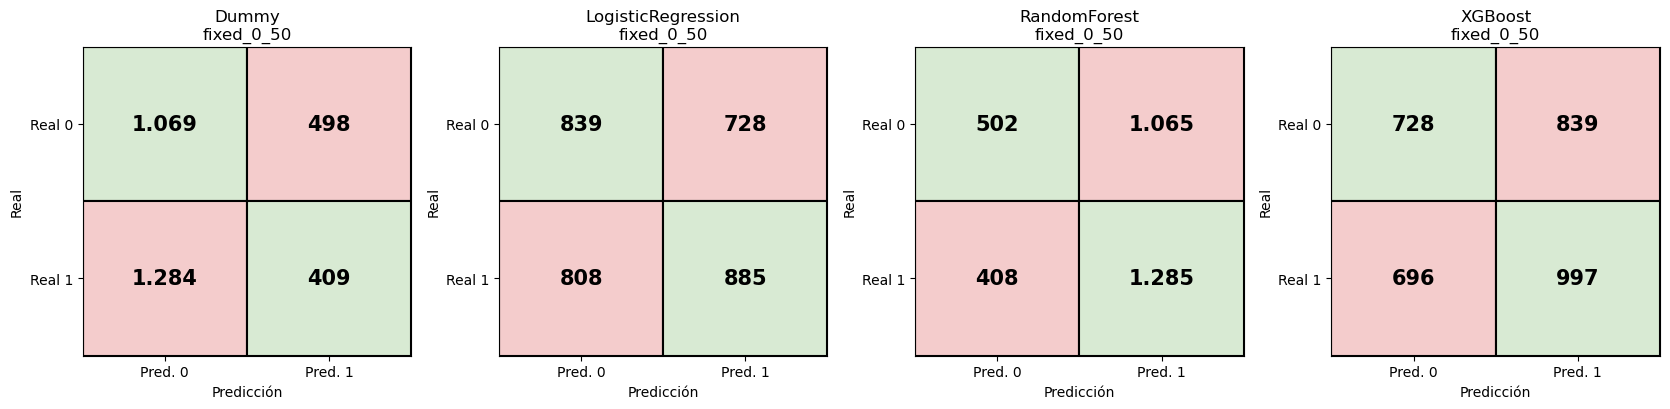

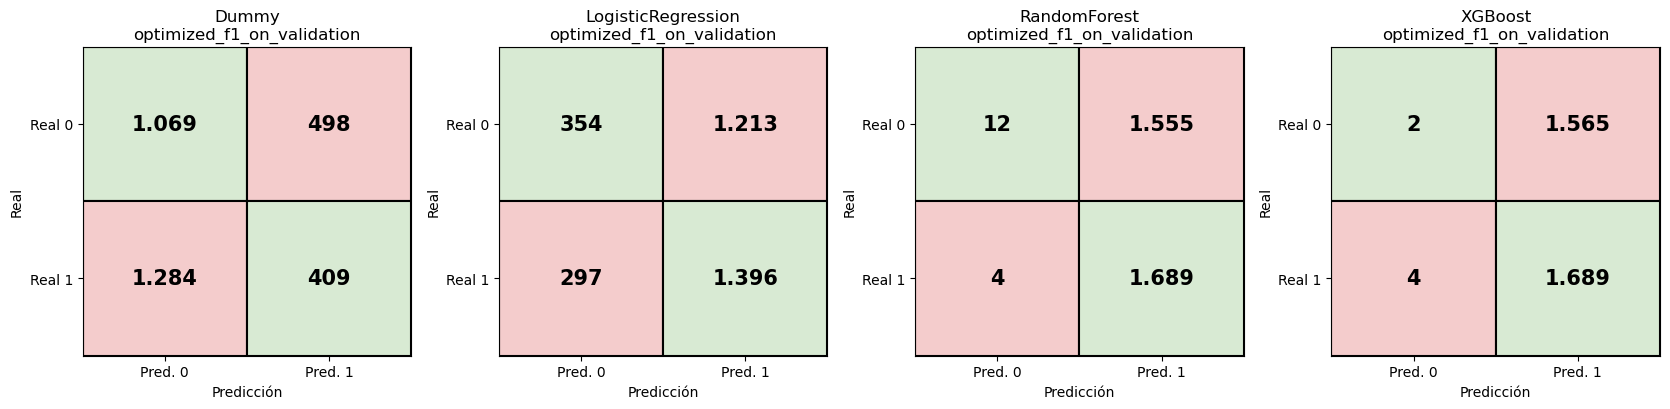

In [10]:
# ============================================================
# 9. Matrices de confusión agregadas por modelo y threshold
# ============================================================

def plot_confusion_grid(conf_df, threshold_strategy, save_path=None):
    sub = conf_df[conf_df['threshold_strategy'] == threshold_strategy].copy()
    models_order = sub['model'].tolist()
    n = len(models_order)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4.2))
    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, sub.iterrows()):
        mat = np.array([[row['tn'], row['fp']], [row['fn'], row['tp']]])
        ax.set_title(f"{row['model']}\n{threshold_strategy}", fontsize=12)
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Pred. 0', 'Pred. 1'], fontsize=10)
        ax.set_yticklabels(['Real 0', 'Real 1'], fontsize=10)
        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(1.5, -0.5)

        # Celdas: aciertos verde claro, errores rojo claro.
        for i in range(2):
            for j in range(2):
                is_correct = i == j
                color = '#D8EAD3' if is_correct else '#F4CCCC'
                rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=color, edgecolor='black', linewidth=1.5)
                ax.add_patch(rect)
                ax.text(j, i, f"{int(mat[i, j]):,}".replace(',', '.'), ha='center', va='center', fontsize=15, fontweight='bold')
        ax.set_xlabel('Predicción')
        ax.set_ylabel('Real')

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()

plot_confusion_grid(metrics_mean, 'fixed_0_50', CONF_DIR / 'confusion_aggregated_fixed_0_50.png')
plot_confusion_grid(metrics_mean, 'optimized_f1_on_validation', CONF_DIR / 'confusion_aggregated_optimized_f1.png')

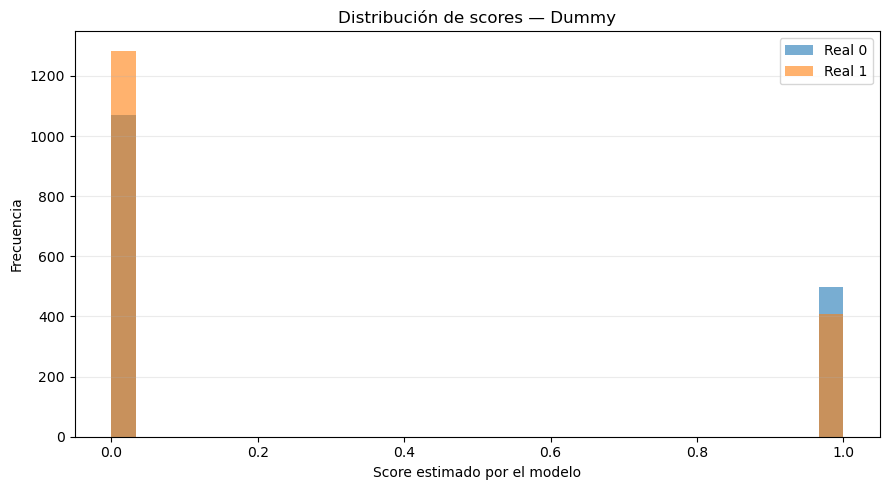

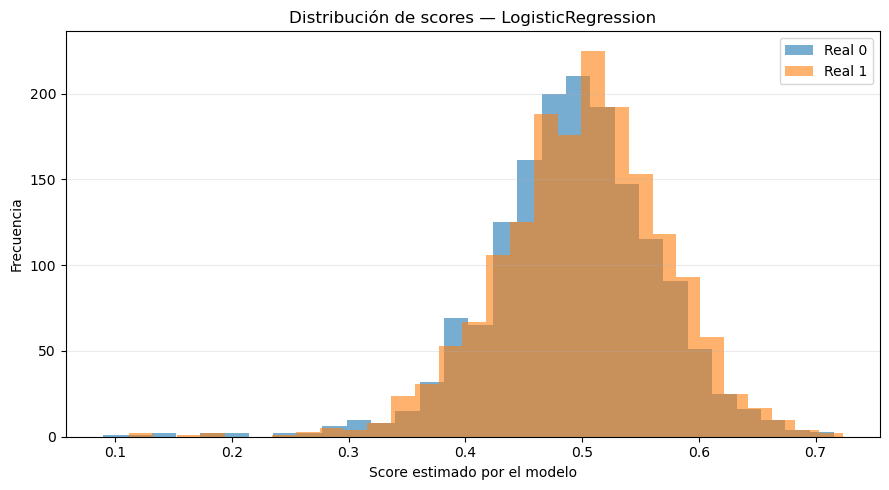

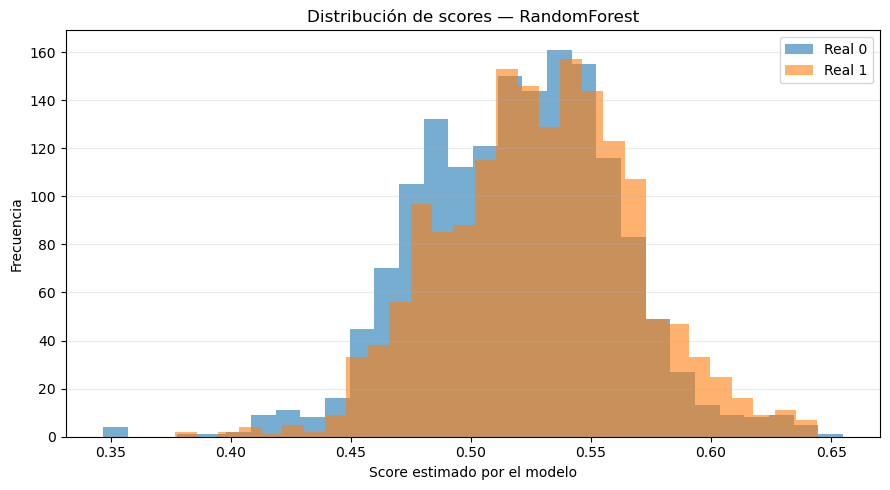

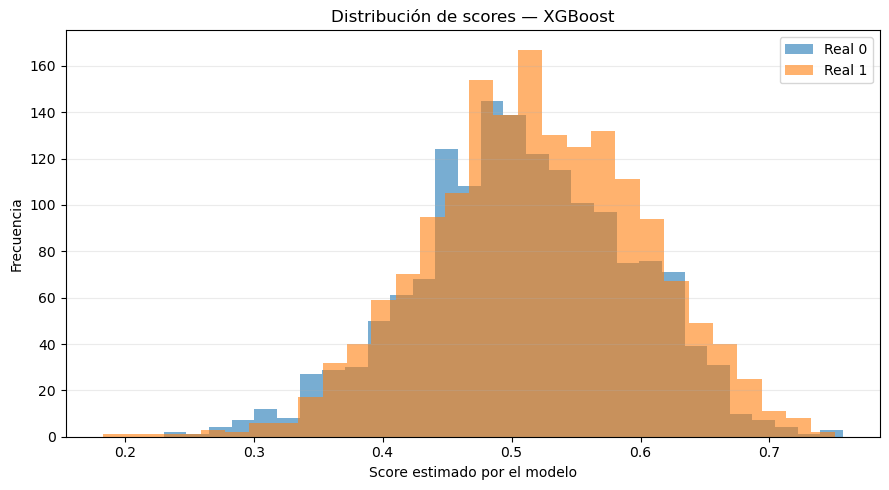

In [11]:
# ============================================================
# 10. Distribución de scores por modelo
# ============================================================

# Se grafican scores agregados de los años de test walk-forward.
for model_name in predictions_df['model'].unique():
    sub = predictions_df[predictions_df['model'] == model_name].copy()
    plt.figure(figsize=(9, 5))
    plt.hist(sub.loc[sub[TARGET_COL] == 0, 'score'], bins=30, alpha=0.60, label='Real 0')
    plt.hist(sub.loc[sub[TARGET_COL] == 1, 'score'], bins=30, alpha=0.60, label='Real 1')
    plt.title(f'Distribución de scores — {model_name}')
    plt.xlabel('Score estimado por el modelo')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.savefig(SCORE_DIR / f'score_distribution_{model_name}.png', dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()

,model,score_decile,n_mean,success_rate,mean_return,median_return
0,Dummy,1,109.000000,0.464435,0.013229,-0.008085
1,Dummy,2,108.666667,0.444429,0.008769,-0.006542
2,Dummy,3,108.333333,0.488094,0.019933,-0.010238
3,Dummy,4,109.000000,0.497936,0.016453,0.003290
4,Dummy,5,108.666667,0.568399,0.034765,0.015807
5,Dummy,6,108.000000,0.441412,0.008483,-0.018671
6,Dummy,7,109.000000,0.465660,0.005886,-0.007071
7,Dummy,8,108.333333,0.550957,0.026120,0.014580
8,Dummy,9,108.666667,0.593349,0.034188,0.017871
9,Dummy,10,109.000000,0.562609,0.047627,0.023391


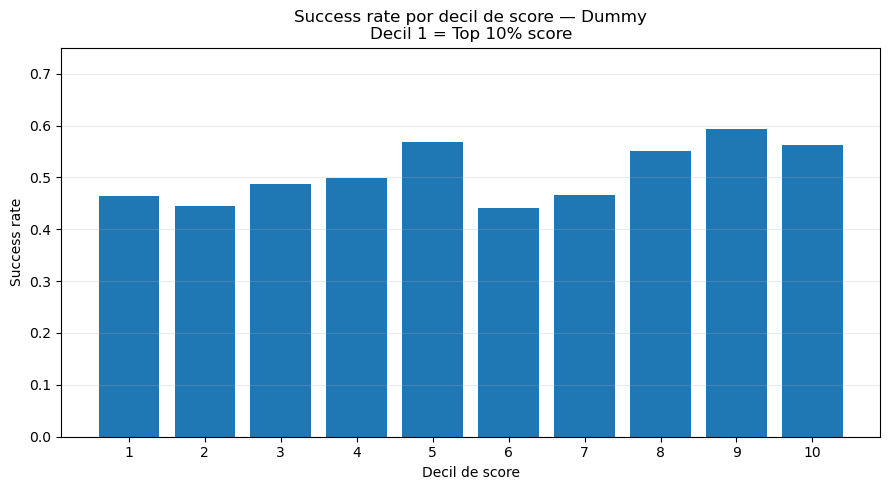

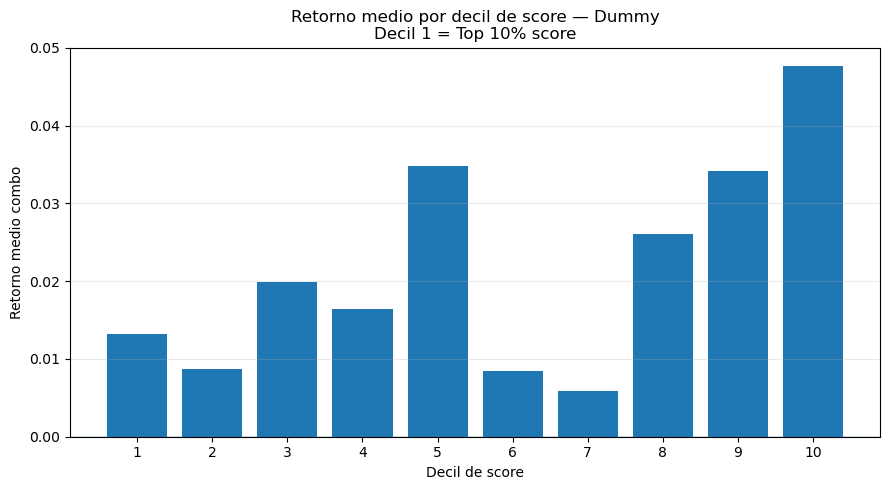

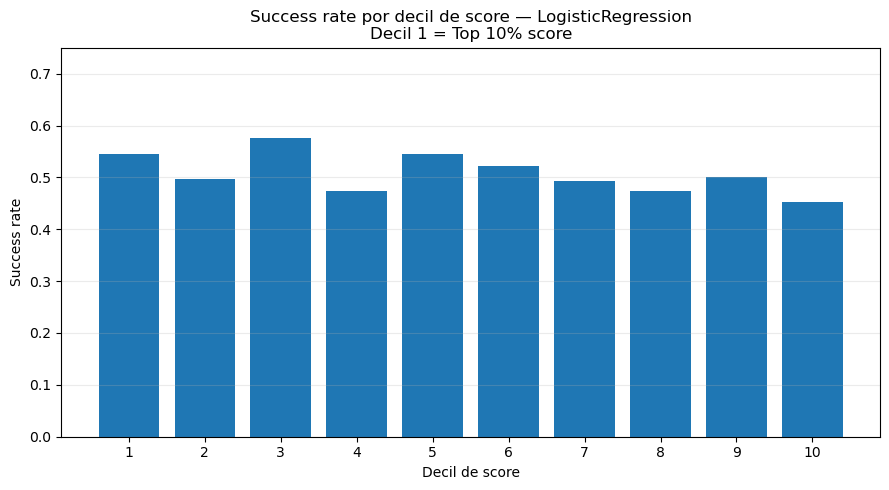

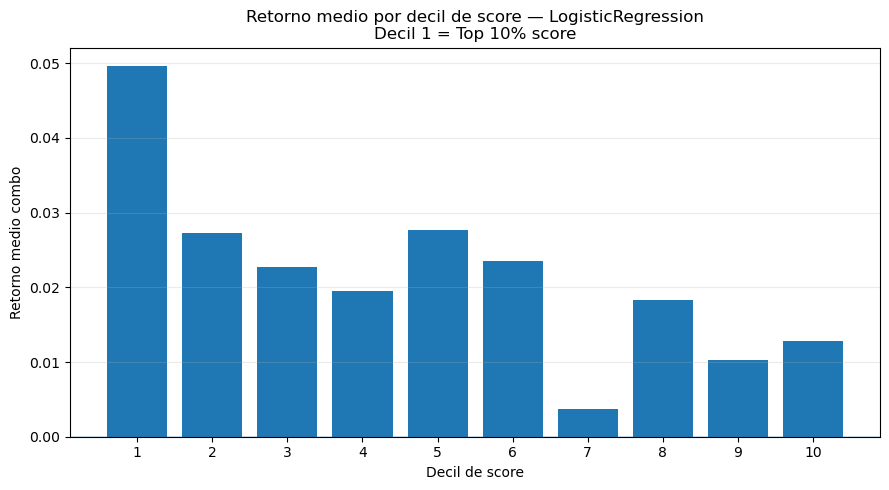

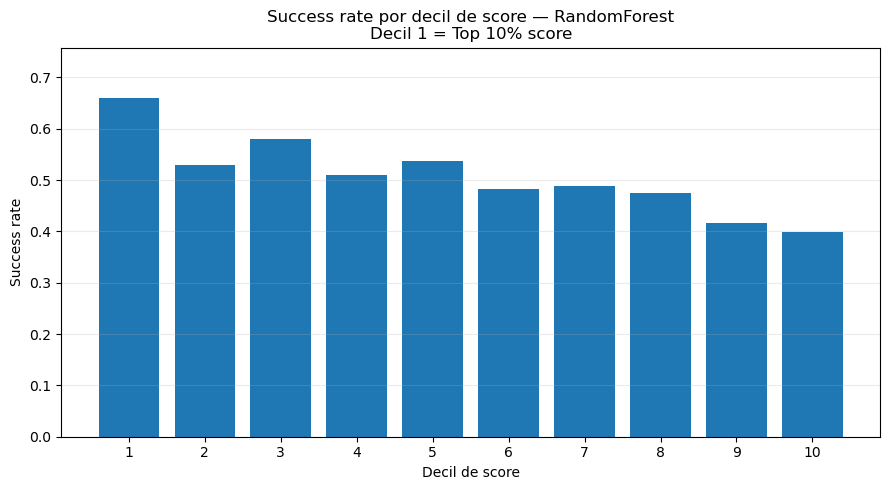

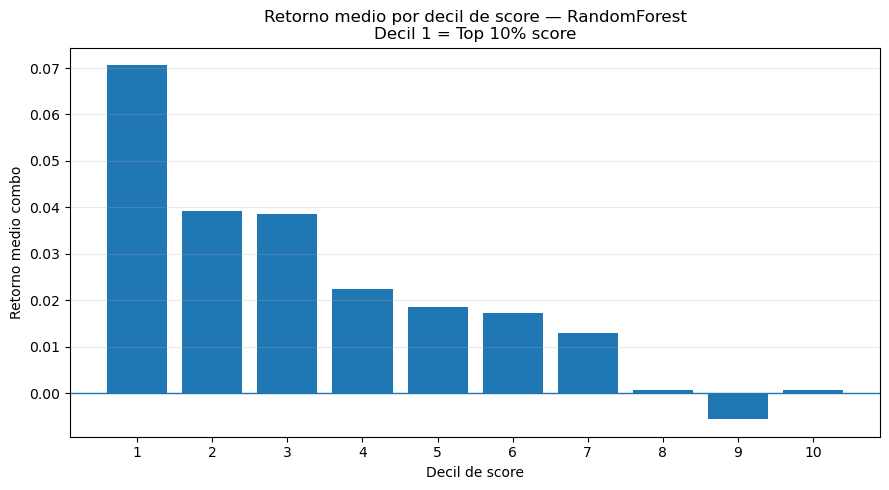

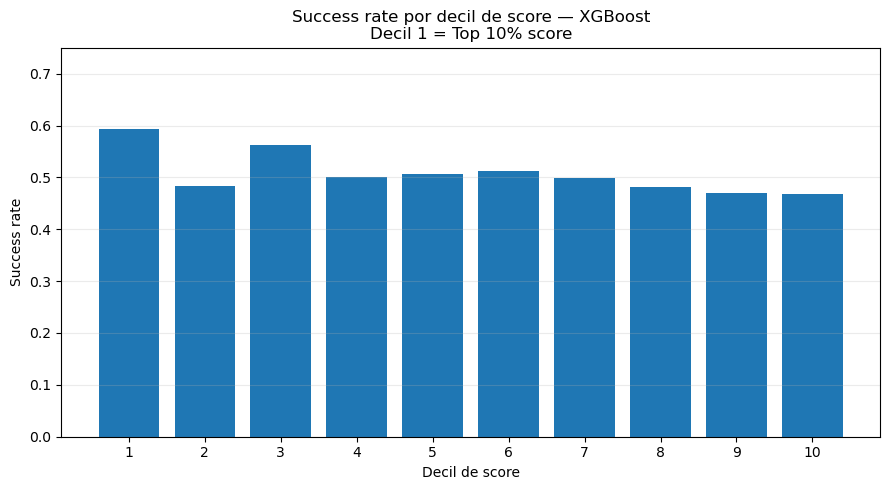

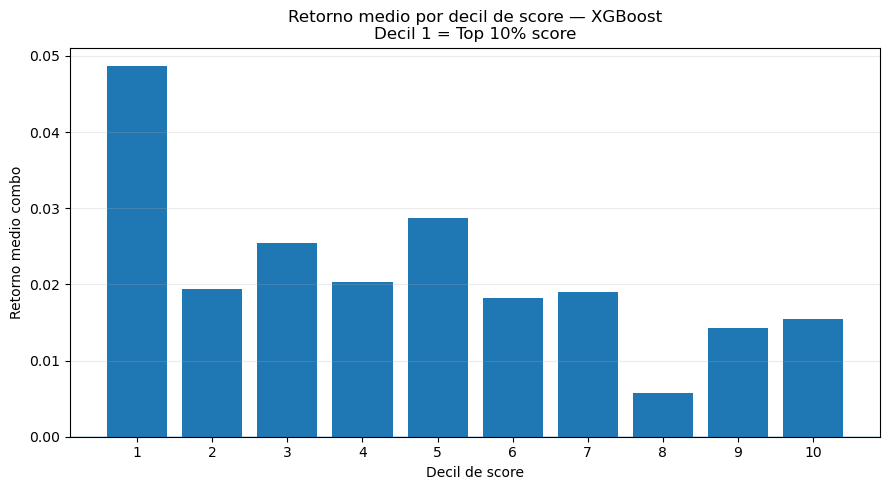

In [12]:
# ============================================================
# 11. Deciles de score: success rate y retorno medio
# ============================================================

if not deciles_mean.empty:
    display(deciles_mean.sort_values(['model', 'score_decile']))

    for model_name in deciles_mean['model'].unique():
        sub = deciles_mean[deciles_mean['model'] == model_name].sort_values('score_decile')

        # Gráfico 1: success rate por decil
        plt.figure(figsize=(9, 5))
        plt.bar(sub['score_decile'].astype(str), sub['success_rate'])
        plt.title(f'Success rate por decil de score — {model_name}\nDecil 1 = Top 10% score')
        plt.xlabel('Decil de score')
        plt.ylabel('Success rate')
        plt.ylim(0, max(0.75, sub['success_rate'].max() * 1.15))
        plt.grid(axis='y', alpha=0.25)
        plt.tight_layout()
        plt.savefig(DECILE_DIR / f'deciles_success_rate_{model_name}.png', dpi=200, bbox_inches='tight')
        plt.show()
        plt.close()

        # Gráfico 2: retorno medio por decil
        plt.figure(figsize=(9, 5))
        plt.bar(sub['score_decile'].astype(str), sub['mean_return'])
        plt.title(f'Retorno medio por decil de score — {model_name}\nDecil 1 = Top 10% score')
        plt.xlabel('Decil de score')
        plt.ylabel('Retorno medio combo')
        plt.axhline(0, linewidth=1)
        plt.grid(axis='y', alpha=0.25)
        plt.tight_layout()
        plt.savefig(DECILE_DIR / f'deciles_mean_return_{model_name}.png', dpi=200, bbox_inches='tight')
        plt.show()
        plt.close()
else:
    print('No hay datos de deciles para mostrar.')


,model,feature_transformed,importance_mean,importance_std
29,RandomForest,num__feat_regime_market_vol_20d_mean,0.214041,0.019377
20,RandomForest,num__feat_regime_breadth_chikou_sobre_kumo,0.072761,0.006952
23,RandomForest,num__feat_regime_breadth_kumo_actual_alcista,0.069313,0.023020
25,RandomForest,num__feat_regime_breadth_precio_sobre_kumo,0.054359,0.008056
24,RandomForest,num__feat_regime_breadth_kumo_futuro_alcista,0.050251,0.008126
28,RandomForest,num__feat_regime_market_ret_5d_mean,0.042698,0.006106
27,RandomForest,num__feat_regime_market_ret_20d_mean,0.040626,0.010256
30,RandomForest,num__feat_regime_market_volume_rel_mean,0.039663,0.009359
21,RandomForest,num__feat_regime_breadth_entry_events,0.039445,0.002411
26,RandomForest,num__feat_regime_breadth_tenkan_sobre_kijun,0.033612,0.002576


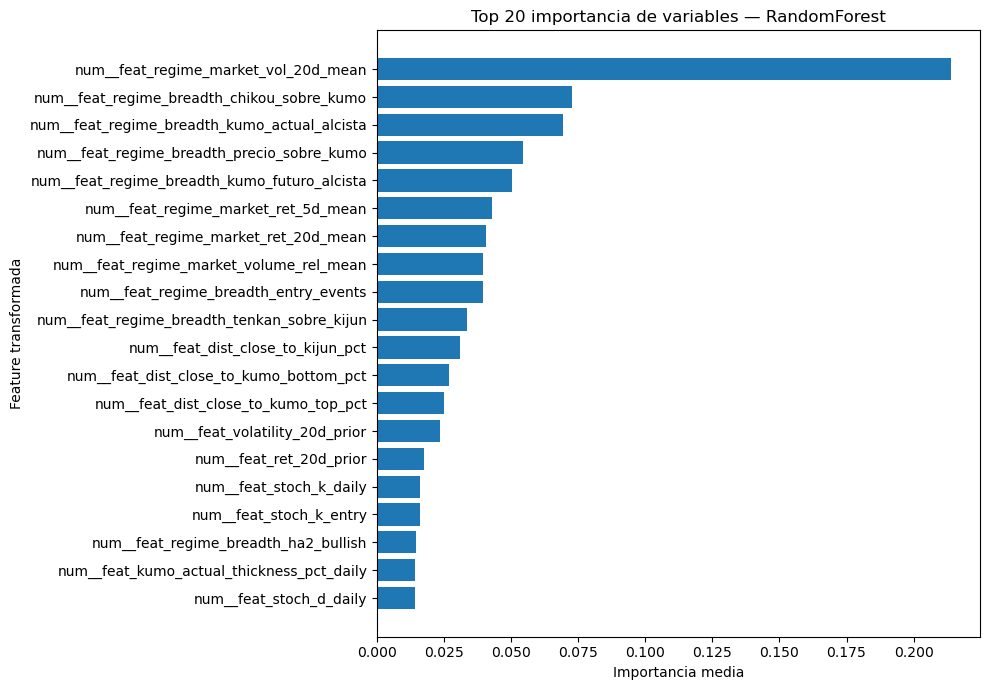

,model,feature_transformed,importance_mean,importance_std
78,XGBoost,num__feat_regime_market_vol_20d_mean,0.069198,0.007065
72,XGBoost,num__feat_regime_breadth_kumo_actual_alcista,0.038208,0.003466
73,XGBoost,num__feat_regime_breadth_kumo_futuro_alcista,0.038015,0.003722
69,XGBoost,num__feat_regime_breadth_chikou_sobre_kumo,0.037400,0.004546
74,XGBoost,num__feat_regime_breadth_precio_sobre_kumo,0.035045,0.002606
76,XGBoost,num__feat_regime_market_ret_20d_mean,0.032345,0.003801
75,XGBoost,num__feat_regime_breadth_tenkan_sobre_kijun,0.031485,0.001891
58,XGBoost,num__feat_chikou_above_close_22ago,0.030573,0.026603
61,XGBoost,num__feat_dist_close_to_kijun_pct,0.029772,0.004006
79,XGBoost,num__feat_regime_market_volume_rel_mean,0.029711,0.009178


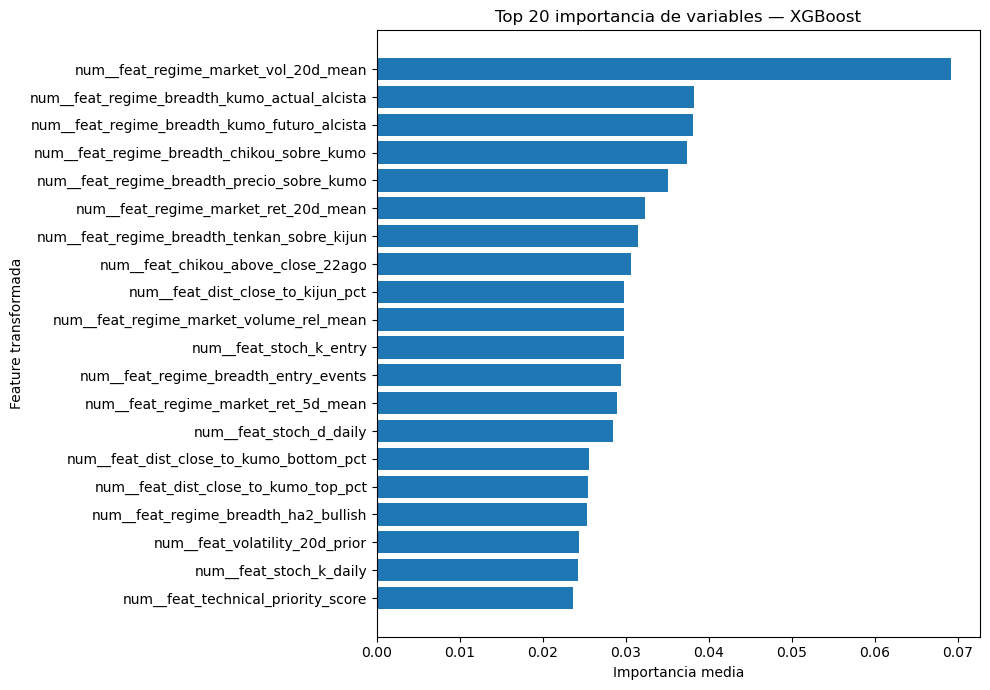

In [13]:
# ============================================================
# 12. Importancia de variables para modelos de árbol
# ============================================================

if not importance_mean.empty:
    for model_name in importance_mean['model'].unique():
        sub = importance_mean[importance_mean['model'] == model_name].head(20).sort_values('importance_mean')
        display(importance_mean[importance_mean['model'] == model_name].head(20))
        plt.figure(figsize=(10, 7))
        plt.barh(sub['feature_transformed'], sub['importance_mean'])
        plt.title(f'Top 20 importancia de variables — {model_name}')
        plt.xlabel('Importancia media')
        plt.ylabel('Feature transformada')
        plt.tight_layout()
        plt.savefig(IMPORTANCE_DIR / f'feature_importance_top20_{model_name}.png', dpi=200, bbox_inches='tight')
        plt.show()
    plt.close()
else:
    print('No hay importancia de variables disponible para los modelos entrenados.')